In [74]:
import os, pickle

import sys
sys.path.insert(1, '..')

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from datasets import jointlikelihood
from models import alice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.preprocessing import StandardScaler
import hist

import torch
from lightning import Trainer

In [75]:
OUTPUT_DIR = '../jobs/alice/refactor-four-BKG-vs-SIG'
SCALER_FILE_X = 'scaler.pkl'
SCALER_FILE_Y = None
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

EPOCH = 53
VAL_LOSS = 0.41
VERSION = 0

CHECKPOINT = f'checkpoint-alice-epoch={EPOCH}-val_loss={VAL_LOSS}.ckpt'
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_NUMERATOR = msq.Component.BKG
COMPONENT_DENOMINATOR = msq.Component.SIG

COMPONENT_FILE = msq.Component.SIG

SAMPLE_SIZE = 150000

FEATURES=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

BATCH_SIZE = 256
SEED = 42

In [76]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

comp_strings = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.BKG : 'BKG',
    msq.Component.INT : 'INT'
}

In [77]:
datamodule = jointlikelihood.AliceDataModule(
    filepath=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]),
    features=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity'],
    numerator_component=COMPONENT_NUMERATOR,
    denominator_component=COMPONENT_DENOMINATOR,
    sample_size=SAMPLE_SIZE,
    batch_size=BATCH_SIZE,
    random_state=SEED,
    scaler_path=None
)

In [78]:
events = sample.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_FILE, COMPONENT_DENOMINATOR)
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

events_processed = events.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

0.0904884168821448


In [79]:
events_train, events_val = events_processed.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)

training_data = jointlikelihood.JointLikelihoodDataset(events_train, features=FEATURES, numerator_component=COMPONENT_NUMERATOR, denominator_component=COMPONENT_DENOMINATOR, sample_size=SAMPLE_SIZE, random_state=SEED)
validation_data = jointlikelihood.JointLikelihoodDataset(events_val, features=FEATURES, numerator_component=COMPONENT_NUMERATOR, denominator_component=COMPONENT_DENOMINATOR, sample_size=SAMPLE_SIZE, random_state=SEED)


if SCALER_FILE_X is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE_X), 'rb') as f:
        scaler_X = pickle.load(f)
    
    training_data.X = scaler_X.transform(training_data.X)
    validation_data.X = scaler_X.transform(validation_data.X)

if SCALER_FILE_Y is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE_Y), 'rb') as f:
        scaler_s = pickle.load(f)
    
    training_data.s = scaler_s.transform(training_data.s)
    validation_data.s = scaler_s.transform(validation_data.s)

In [80]:
loaded_model = alice.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [81]:
predictions_train = loaded_model(torch.tensor(training_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_train = training_data.s

In [82]:
predictions_val = loaded_model(torch.tensor(validation_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_val = validation_data.s

In [83]:
targets_train=training_data.s
targets_val=validation_data.s

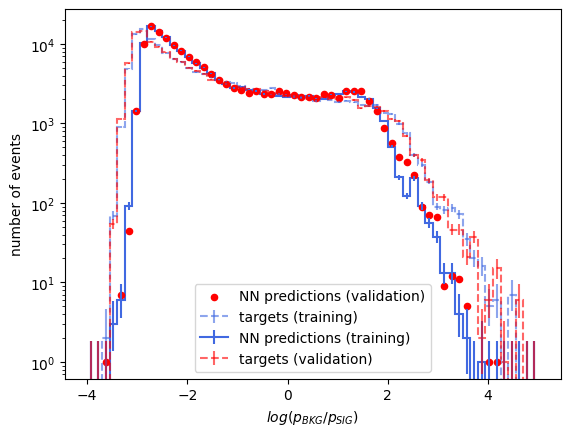

In [84]:
BINS = 60

bounds = [-4,5]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(np.log(predictions_train/(1-predictions_train)))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(np.log(targets_train/(1-targets_train)))


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_val.fill(np.log(predictions_val/(1-predictions_val)))

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_val.fill(np.log(targets_val/(1-targets_val)))

h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')

bin_centers = h_predictions_val.axes[0].centers
bin_heights = h_predictions_val.values()

h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')

plt.xlabel(f'$log(p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}})$')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

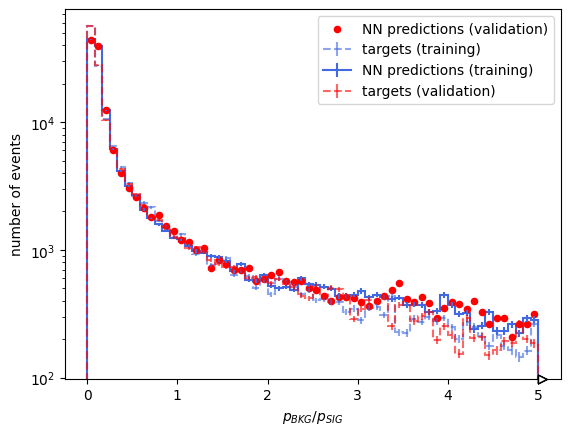

In [93]:
BINS = 60

bounds = [0,5]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions_train/(1-predictions_train))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(targets_train/(1-targets_train))


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_val.fill(predictions_val/(1-predictions_val))

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_val.fill(targets_val/(1-targets_val))

h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')

bin_centers = h_predictions_val.axes[0].centers
bin_heights = h_predictions_val.values()

h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')

plt.xlabel(f'$p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}}$')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

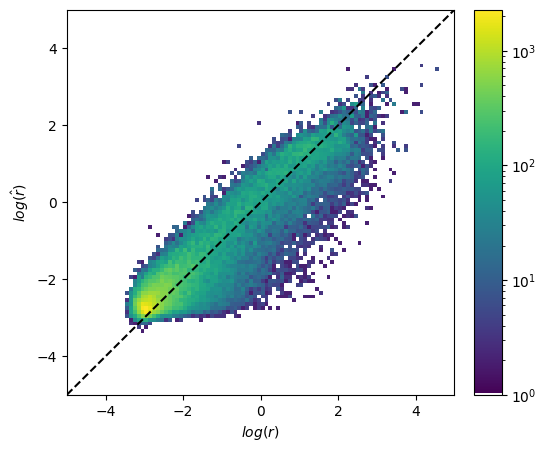

In [86]:
BINS=100

bounds = [-5,5]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
)

h_calibration_val.fill(np.log(targets_val/(1-targets_val)), np.log(predictions_val/(1-predictions_val)))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

plt.show()

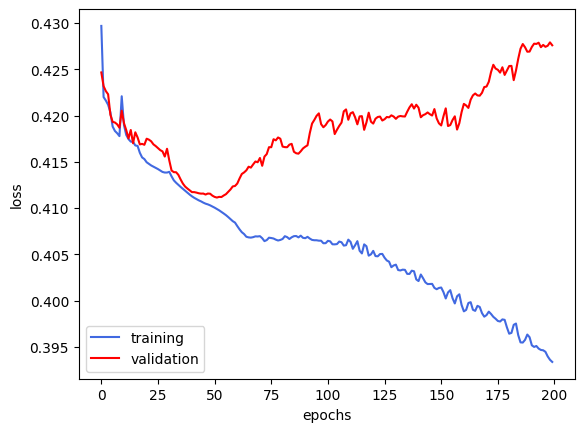

In [87]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.yscale('log')
plt.legend()
plt.show()